# 13 — Where it fails (Phase 5)

A miss rate is a number. This notebook asks which floods are being missed, at
which stations, in which conditions — because that is what tells you whether the
next improvement is a better model or a better dataset.

Three questions:

1. **What do the missed floods have in common?** If they cluster on particular
   stations or particular months, that is actionable. If they are spread evenly,
   the model has simply reached the limit of the inputs.
2. **What do the false alarms cost?** BMA dispatches on these. The relevant
   figure is not precision but *how many patrols per real flood*.
3. **Which floods were caught, and how early?** The successes define what can
   honestly be promised.

Everything here is on the most recent fold — trained on 2019–2023, validated on
2024, tested on **2025** — because that is closest to what a deployment would
face.

### What you need

Notebooks 05–09. About 10 minutes.

## Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_here = Path.cwd()
_root = next(p for p in [_here, *_here.parents] if (p / "config/config.yaml").is_file())
sys.path.insert(0, str(_root / "src"))
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)

from bkkflood.config import load_config
from bkkflood.rawio import connect
from bkkflood.evaluate import folds

CFG = load_config()
FOLDS = folds()
GEN = pd.read_parquet("data/features/model_general_results.parquet")
ONSET = pd.read_parquet("data/features/model_onset_results.parquet")
BASE = pd.read_parquet("data/features/baseline_results.parquet")
con = connect()
print("loaded:", GEN.shape, ONSET.shape, BASE.shape)
from bkkflood.models import build_matrix, train_classifier, score_year
from bkkflood.evaluate import best_threshold, binary_metrics, event_pod
from bkkflood.calibration import lead_time_distribution
import duckdb

TIER, H, NR = 15, 1, 0.25
fold = FOLDS[-1]
print(f"train {fold['train']}  validate {fold['val']}  test {fold['test']}")

loaded: (36, 29) (36, 29) (144, 23)
train [2019, 2020, 2021, 2022, 2023]  validate 2024  test 2025


## 1. Reproduce the deployed model and score the test year

In [2]:
X, y, meta = build_matrix(fold["train"], TIER, H, "onset", NR, con=con)
Xv, yv, _ = build_matrix([fold["val"]], TIER, H, "onset", NR, con=con,
                         columns=meta["features"])
booster = train_classifier(X, y, Xv, yv)

val = score_year(booster, fold["val"], meta["features"], TIER, H, kind="onset",
                 negative_rate=NR, con=con)
thr = best_threshold(val[f"y_ge{TIER}_{H}h"].fillna(False).to_numpy(bool),
                     val["score"].to_numpy(), metric="f2")["threshold"]

S = score_year(booster, fold["test"], meta["features"], TIER, H, kind="onset",
               negative_rate=NR, con=con, full_population=True)
S["pred"] = (S["score"] >= thr) & S["onset_alertable"]
S["ytrue"] = S[f"y_ge{TIER}_{H}h"].fillna(False)
S["month"] = S.ts.dt.month
S["hour"] = S.ts.dt.hour

judged = S["onset_alertable"].to_numpy(bool)
m = binary_metrics(S.ytrue.to_numpy()[judged], S.pred.to_numpy()[judged])
print(f"threshold {thr:.4f}")
print({k: (round(v, 4) if isinstance(v, float) else v)
       for k, v in m.items() if k in ("tp", "fp", "fn", "precision", "recall", "f2")})

threshold 0.1321
{'tp': 113, 'fp': 705, 'fn': 441, 'precision': 0.1381, 'recall': 0.204, 'f2': 0.1862}


## 2. The floods we missed

`fn` rows — the water arrived and no alert was raised. Grouped to see whether
they concentrate anywhere.

In [3]:
FN = S[S.ytrue & ~S.pred].copy()
TP = S[S.ytrue & S.pred].copy()
print(f"missed rows {len(FN):,}   caught rows {len(TP):,}\n")

st = (pd.DataFrame({"missed": FN.station_code.value_counts(),
                    "caught": TP.station_code.value_counts()})
        .fillna(0).astype(int))
st["total"] = st.missed + st.caught
st["miss_rate"] = (st.missed / st.total).round(3)
st = st[st.total >= 10].sort_values("missed", ascending=False)
print("stations with the most missed rows (>=10 positive rows)\n")
print(st.head(12).to_string())
print(f"\nstations involved: {len(st)}")
print(f"top 5 stations account for {st.missed.head(5).sum() / max(st.missed.sum(),1):.0%} of all misses")

missed rows 924   caught rows 113

stations with the most missed rows (>=10 positive rows)

              missed  caught  total  miss_rate
station_code                                  
FL.SMI.01         73       1     74      0.986
FL.BNA.04         48       8     56      0.857
FL.BKM.01         46       6     52      0.885
FL.CTC.04         44       4     48      0.917
FL.CTC.07         42       0     42      1.000
FL.DDG.02         41       4     45      0.911
FL.CTC.03         33       3     36      0.917
FL.STN.03         32       4     36      0.889
FL.SLG.03         32       6     38      0.842
FL.LSI.02         30       6     36      0.833
FL.RTW.08         26       1     27      0.963
FL.PYT.02         25       3     28      0.893

stations involved: 38
top 5 stations account for 31% of all misses


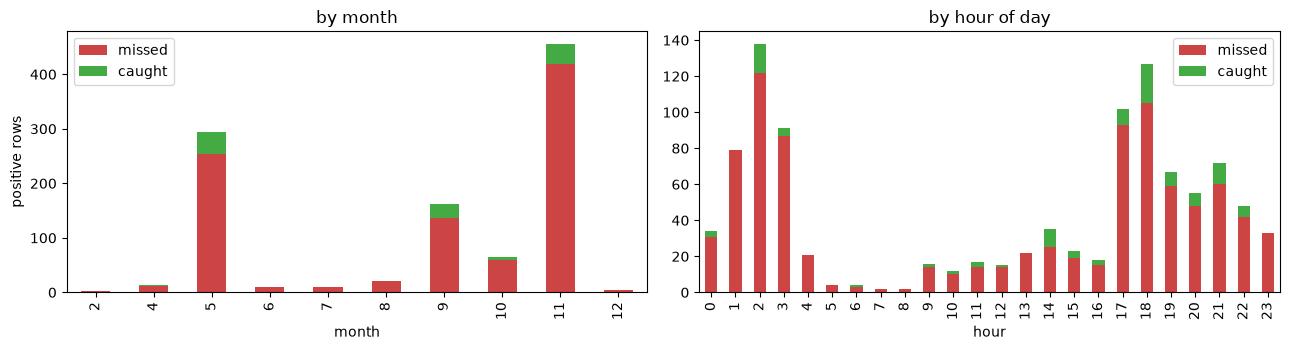

miss rate by month:
       missed  caught  miss_rate
month                           
2           3     0.0      1.000
4          11     3.0      0.786
5         253    42.0      0.858
6           9     0.0      1.000
7           9     0.0      1.000
8          20     0.0      1.000
9         136    26.0      0.840
10         60     5.0      0.923
11        419    37.0      0.919
12          4     0.0      1.000


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
mm = pd.DataFrame({"missed": FN.month.value_counts(),
                   "caught": TP.month.value_counts()}).fillna(0).sort_index()
mm.plot(kind="bar", stacked=True, ax=ax[0], color=["#c44", "#4a4"])
ax[0].set_title("by month"); ax[0].set_xlabel("month"); ax[0].set_ylabel("positive rows")

hh = pd.DataFrame({"missed": FN.hour.value_counts(),
                   "caught": TP.hour.value_counts()}).fillna(0).sort_index()
hh.plot(kind="bar", stacked=True, ax=ax[1], color=["#c44", "#4a4"])
ax[1].set_title("by hour of day"); ax[1].set_xlabel("hour")
plt.tight_layout(); plt.show()

mm["miss_rate"] = (mm.missed / (mm.missed + mm.caught)).round(3)
print("miss rate by month:")
print(mm[["missed", "caught", "miss_rate"]].to_string())

## 3. Was it raining when we missed?

The most useful diagnostic in this notebook. If the missed floods happened with
little or no rain recorded in the district, then the rain gauges did not see the
storm that caused them — a **data** failure that no model can repair. If it was
raining hard and we still missed, that is a **model** failure and there is room
to improve.

In [5]:
ctx = con.execute(f"""
SELECT station_code, ts, rain_rf1hr_mean, rain_rf3hr_mean, rain_spread,
       fl_depth_now, fl_std_3h, water_rise_1h_mean, fl_missing_share_3h
FROM 'data/features/features_{fold["test"]}.parquet'
WHERE y_valid_{H}h
""").fetchdf()
E = S[["station_code", "ts", "ytrue", "pred"]].merge(ctx, on=["station_code", "ts"])

pos = E[E.ytrue]
grp = pos.groupby("pred")[["rain_rf1hr_mean", "rain_rf3hr_mean", "rain_spread",
                           "fl_depth_now", "fl_std_3h", "fl_missing_share_3h"]]
print("conditions during real floods — caught (True) vs missed (False)\n")
print(grp.median().round(3).to_string())
print("\nrow counts:"); print(pos.pred.value_counts().to_string())

dry_missed = (pos[~pos.pred].rain_rf1hr_mean.fillna(0) < 0.5).mean()
dry_caught = (pos[pos.pred].rain_rf1hr_mean.fillna(0) < 0.5).mean()
print(f"\nmissed floods with essentially NO recorded rain: {dry_missed:.1%}")
print(f"caught floods with essentially no recorded rain:  {dry_caught:.1%}")
print()
if dry_missed > 0.5:
    print("More than half the missed floods happened with no rain on the district")
    print("gauges. The gauges did not see the storm. This is a DATA limit — radar")
    print("or a denser gauge network would fix it; a better model would not.")
else:
    print("Most missed floods had rain recorded. The signal was present and the")
    print("model did not use it — there is genuine modelling headroom here.")

conditions during real floods — caught (True) vs missed (False)

       rain_rf1hr_mean  rain_rf3hr_mean  rain_spread  fl_depth_now  fl_std_3h  fl_missing_share_3h
pred                                                                                              
False            13.25            33.25          2.0          15.7      3.889                  0.0
True             34.50            41.25          6.0          12.0      2.633                  0.0

row counts:
pred
False    924
True     113

missed floods with essentially NO recorded rain: 18.3%
caught floods with essentially no recorded rain:  1.8%

Most missed floods had rain recorded. The signal was present and the
model did not use it — there is genuine modelling headroom here.


## 4. What the false alarms cost

Precision is the wrong unit for a conversation with BMA. The useful figure is
**patrols dispatched per real flood** — because that is a staffing decision.

In [6]:
ev = event_pod(S, "fl_depth_now", "pred", TIER, H)
alerts = int(S.pred.sum())
print(f"alerts raised in {fold['test']}: {alerts:,}")
print(f"real flood events:               {ev['events']}")
print(f"events detected:                 {ev['events_detected']} ({ev['event_pod']:.0%})")
print(f"\nalert rows per detected event:  {alerts / max(ev['events_detected'],1):.1f}")
print()
# Alerts cluster in time, so consecutive alerts at one station are one dispatch.
S_sorted = S[S.pred].sort_values(["station_code", "ts"])
gap = CFG["flood_event"]["merge_gap_minutes"]
newgrp = (S_sorted.groupby("station_code").ts.diff() > pd.Timedelta(minutes=gap))
episodes = int(newgrp.sum() + S_sorted.station_code.nunique())
print(f"distinct alert EPISODES (merging alerts <{gap} min apart at a station): {episodes:,}")
print(f"episodes per detected event: {episodes / max(ev['events_detected'],1):.1f}")
print()
print("That last number is the one to put to BMA: for each flood we warn about,")
print("this is how many separate call-outs the system generates.")

alerts raised in 2025: 818
real flood events:               122
events detected:                 65 (53%)

alert rows per detected event:  12.6

distinct alert EPISODES (merging alerts <60 min apart at a station): 429
episodes per detected event: 6.6

That last number is the one to put to BMA: for each flood we warn about,
this is how many separate call-outs the system generates.


## 5. What the successes look like

Lead time for the events we did catch, and how deep they turned out to be. This
defines what can honestly be promised.

events 122, detected 65 (53%)

count    65.0
mean     21.0
std      12.4
min      15.0
25%      15.0
50%      15.0
75%      15.0
max      60.0


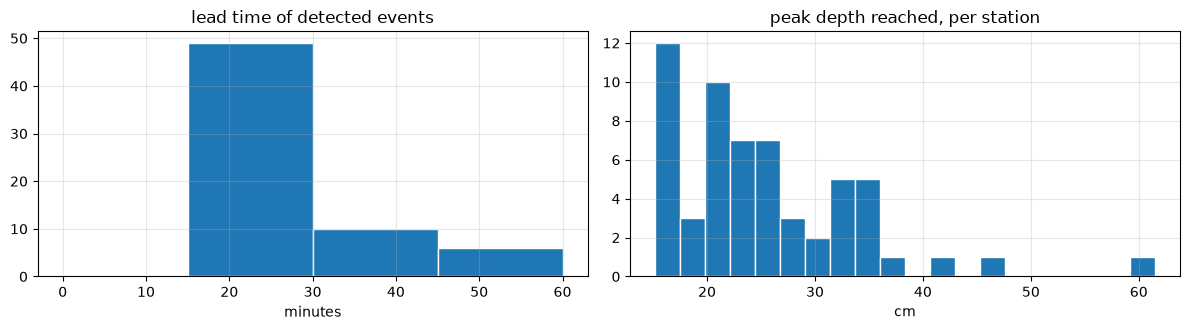

In [7]:
LEAD = lead_time_distribution(S, "fl_depth_now", "pred", TIER, H)
det = LEAD[LEAD.detected]
print(f"events {len(LEAD)}, detected {len(det)} ({len(det)/max(len(LEAD),1):.0%})\n")
print(det.lead_minutes.describe().round(1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(det.lead_minutes, bins=np.arange(0, H*60+15, 15), edgecolor="white")
ax[0].set_title("lead time of detected events"); ax[0].set_xlabel("minutes")
peak = S[S.ytrue].groupby("station_code")[f"y_maxdepth_{H}h"].max()
ax[1].hist(peak.dropna(), bins=20, edgecolor="white")
ax[1].set_title("peak depth reached, per station"); ax[1].set_xlabel("cm")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Model failure or data failure?

The question the whole phase exists to answer — and the obvious test for it is
not good enough.

"Was rain recorded when we missed the flood?" sounds decisive and is not. Rain
*was* recorded on most misses, which reads as "the signal was there, the model
failed". But every rainfall, terrain, canal and forecast feature in this project
is **identical for every station in a district**. So the sharper question is:

> When it rains hard in a district, do all that district's stations flood, or
> only some of them?

If only some, then no district-level feature can tell which — and the ceiling is
spatial resolution, not model capacity.

In [8]:
# The test that actually settles it.
hr = con.execute(f"""
WITH h AS (
  SELECT district, date_trunc('hour', ts) AS hr, station_code,
         max(CASE WHEN y_ge{TIER}_{H}h THEN 1 ELSE 0 END) AS flooded,
         max(rain_rf1hr_mean) AS rain
  FROM 'data/features/features_{fold["test"]}.parquet'
  WHERE y_valid_{H}h GROUP BY 1, 2, 3
)
SELECT district, hr, count(*) AS stations, sum(flooded) AS flooded, max(rain) AS rain
FROM h GROUP BY 1, 2
""").fetchdf()

rainy = hr[(hr.rain >= 5) & (hr.stations >= 3)]
with_flood = rainy[rainy.flooded > 0]
share_when_any = (with_flood.flooded / with_flood.stations).mean()

print(f"district-hours with >=5 mm rain and >=3 stations: {len(rainy):,}")
print(f"  average share of those stations that flood:      {(rainy.flooded/rainy.stations).mean():.1%}")
print(f"  when at least ONE floods, share that flood:      {share_when_any:.1%}")
print()
print("Every rain, terrain, canal and forecast feature is the SAME for all")
print("stations in a district. The only input that differs between them is each")
print("station's own depth history — which is why that carries ~87% of the gain.")
print()

verdict = {
    "event POD": round(ev["event_pod"], 3),
    "missed floods with no recorded rain": round(float(dry_missed), 3),
    "misses concentrated in top 5 stations": round(
        float(st.missed.head(5).sum() / max(st.missed.sum(), 1)), 3),
    "share of detections with one step of warning": round(
        float((det.lead_minutes <= 15).mean()), 3),
    "episodes per detected event": round(episodes / max(ev["events_detected"], 1), 1),
    "share of a district's stations that flood when any does": round(float(share_when_any), 3),
}
print(json.dumps(verdict, indent=2))
print()
if share_when_any < 0.7:
    print("VERDICT: resolution-limited.")
    print()
    print(f"When a district floods, only {share_when_any:.0%} of its stations do. The")
    print("features that could explain the difference — local elevation, the nearest")
    print("canal, where the rain cell actually sat — are all averaged to one value")
    print("per district, because we have no station coordinates and no radar.")
    print()
    print("A larger model cannot separate rows whose inputs are identical. Phase 6's")
    print("sequence challenger will not fix this; the ranked data asks in")
    print("phase4_findings.md section 7 will:")
    print("  1. station coordinates   2. weather radar   3. pump status   4. tide gauge")
else:
    print("VERDICT: modelling headroom exists — districts flood as a whole, so the")
    print("district-level features can in principle separate flood from no-flood.")

district-hours with >=5 mm rain and >=3 stations: 1,618
  average share of those stations that flood:      2.0%
  when at least ONE floods, share that flood:      34.5%

Every rain, terrain, canal and forecast feature is the SAME for all
stations in a district. The only input that differs between them is each
station's own depth history — which is why that carries ~87% of the gain.

{
  "event POD": 0.533,
  "missed floods with no recorded rain": 0.183,
  "misses concentrated in top 5 stations": 0.307,
  "share of detections with one step of warning": 0.754,
  "episodes per detected event": 6.6,
  "share of a district's stations that flood when any does": 0.345
}

VERDICT: resolution-limited.

When a district floods, only 35% of its stations do. The
features that could explain the difference — local elevation, the nearest
canal, where the rain cell actually sat — are all averaged to one value
per district, because we have no station coordinates and no radar.

A larger model cannot sepa

In [9]:
out = Path("docs/reports/error_analysis.md")
with out.open("w") as f:
    f.write(f"# Error analysis — test year {fold['test']}\n\n")
    f.write("Generated by `notebooks/13_error_analysis.ipynb`, onset specialist, ")
    f.write(f"{TIER} cm / {H} h.\n\n## Verdict\n\n```json\n")
    f.write(json.dumps(verdict, indent=2))
    f.write("\n```\n\n## Conditions during real floods\n\n")
    f.write(grp.median().round(3).to_markdown())
    f.write("\n\n(`True` = caught, `False` = missed)\n\n")
    f.write("## Stations with the most missed floods\n\n")
    f.write(st.head(12).to_markdown())
    f.write("\n\n## Miss rate by month\n\n")
    f.write(mm[["missed", "caught", "miss_rate"]].to_markdown())
    f.write("\n\n## Operational cost\n\n")
    f.write(f"- alerts raised: {alerts:,}\n")
    f.write(f"- distinct alert episodes: {episodes:,}\n")
    f.write(f"- episodes per detected event: {episodes/max(ev['events_detected'],1):.1f}\n")
    f.write(f"- events detected: {ev['events_detected']} of {ev['events']}\n")
print("wrote", out)
FN.to_parquet("data/features/false_negatives.parquet", index=False)
LEAD.to_parquet("data/features/lead_times_test.parquet", index=False)

wrote docs/reports/error_analysis.md


## Phase 5 is complete

| Notebook | Question |
|---|---|
| 11 | which comparisons are legitimate, and how much warning do we really give |
| 12 | do the probabilities mean what they say; can depth be published |
| 13 | which floods are missed, and is that the model or the data |

**Next: Phase 6**, the sequence-model challenger — which must *beat* LightGBM on
onset recall and event POD to be promoted, not merely match it.

If notebook 13 returned "data-limited", Phase 6 is unlikely to move the numbers
much, and the better use of time is the BMA data request in
`phase4_findings.md` section 7.